# 06 Generate Manuscript Tables

Notebook-first article reproduction. Calculations are kept in notebook cells.

## LaTeX Export
Write manuscript table fragments, number macros, and copy figure files into the manuscript directory.

In [1]:

from pathlib import Path
import json
import math
import pickle
import shutil
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
MANUSCRIPT_FIGURES = FIGURES / "manuscript"
MODELS_DIR = RESULTS / "models"
SPLITS_DIR = RESULTS / "splits"
MANUSCRIPT = ROOT / "manuscript"
GENERATED = MANUSCRIPT / "tables"

for path in [TABLES, MANUSCRIPT_FIGURES, MODELS_DIR, SPLITS_DIR, GENERATED]:
    path.mkdir(parents=True, exist_ok=True)

TARGET_COL = "-lgLD50, mol/kg"
CLUSTER_COL = "Butina_clusters"
BBB_FILTER_COL = "bbb_rule_pass"
LIGAND_ID_COL = "ligand_id"
FP_PREFIX = "FP_"
RANDOM_STATE = 42

PROTEINS = [
    "1m2z", "1pbq", "1xoq", "2rh1", "2vt4", "2ydo", "2z5x", "3b66", "3kk6", "3ln1",
    "3rze", "4djh", "4ey7", "4iar", "4mqs", "4n6h", "5cxv", "5i71", "5tvn", "5u09",
    "5va1", "6cm4", "6kpf", "6kux", "6lqa", "6pdj", "6x3x", "6y1z", "7f8y", "7kwe",
    "7ljd", "7wc9", "7xnk", "7ym8", "8e9y", "8ef6", "8fhs", "8pjk", "8st0", "8wty",
    "8xvk", "8yn3", "9eo4", "V1A",
]
MODEL_ORDER = ["Baseline", "PCA", "ADME", "Plain", "BBB pass"]

from PIL import Image
from IPython.display import display, Image as IPImage


In [2]:

def tex_escape(s: str) -> str:
    return str(s).replace("_", r"\_")

summary = pd.read_csv(TABLES / "summary.csv")
conf_summary = pd.read_csv(TABLES / "conformal_mean_burden_summary.csv").iloc[0]
quadrants = pd.read_csv(TABLES / "conformal_quadrants.csv")
thresholds = pd.read_csv(TABLES / "conformal_quadrant_thresholds.csv").iloc[0]
display_stats = pd.read_csv(TABLES / "conformal_burden_maps_mean_44.csv").iloc[0]
robustness_summary = pd.read_csv(TABLES / "conformal_30_split_robustness_summary.csv").set_index("metric")
coverage_audit = pd.read_csv(TABLES / "conformal_coverage_audit.csv").set_index("method_key")
fallback_audit = pd.read_csv(TABLES / "conformal_fallback_audit.csv").set_index("is_global_fallback")
sensitivity = pd.read_csv(TABLES / "conformal_sensitivity_analysis.csv")
summary = summary.set_index("model").loc[MODEL_ORDER].reset_index()


In [3]:

BR = r"\\"
lines = []
lines.append(r"\begin{table}[!h]")
lines.append(r"\caption{Comparison of regression models from the global model-comparison analysis. Lower RMSE, MAE, MSE, and conformal PI are better; higher $R^2$, Spearman's $\rho$, and CCC are better.\label{tab:model_quality}}")
lines.append(r"\centering")
lines.append(r"\setlength{\tabcolsep}{4pt}")
lines.append(r"\renewcommand{\arraystretch}{1.1}")
lines.append(r"\begin{tabularx}{\textwidth}{l *{6}{r} *{3}{r}}")
lines.append(r"\toprule")
lines.append(r"\textbf{Model} & \textbf{RMSE} & \textbf{MAE} & \textbf{MSE} & $\boldsymbol{R^2}$ & \textbf{Spearman} & \textbf{CCC} & \multicolumn{3}{c}{\textbf{Conformal PI}} \\")
lines.append(r"\cmidrule(lr){8-10}")
lines.append(r"& & & & & & & \textbf{80\%} & \textbf{90\%} & \textbf{95\%} \\")
lines.append(r"\midrule")
for _, row in summary.iterrows():
    if row["model"] == "BBB pass":
        lines.append(r"\midrule")
    lines.append(
        f"{tex_escape(row['model'])} & {row['RMSE']:.3f} & {row['MAE']:.3f} & {row['MSE']:.3f} & "
        f"{row['R2']:.3f} & {row['Spearman']:.3f} & {row['CCC']:.3f} & "
        f"{row['CI_0.8_size']:.3f} & {row['CI_0.9_size']:.3f} & {row['CI_0.95_size']:.3f} {BR}")
lines.append(r"\bottomrule")
lines.append(r"\end{tabularx}")
lines.append(r"\end{table}")
(GENERATED / "table1_model_quality.tex").write_text("\n".join(lines) + "\n")
comparison_summary = TABLES / "model_comparison_summary.csv"
if comparison_summary.is_file():
    subprocess.run([sys.executable, str(ROOT / "scripts" / "build_model_comparison_table.py")], check=True)
print("wrote table1")


Wrote: /home/safronov/code/opencode/tox/reporev2j/manuscript/tables/table1_model_quality.tex
wrote table1


In [4]:
map_min = float(display_stats.get("interval_width_display_min", np.nan))
map_max = float(display_stats.get("interval_width_display_max", np.nan))
global_cov = coverage_audit.loc["global_split_conformal"]
local_cov = coverage_audit.loc["local_joint"]
localized_subset = fallback_audit.loc[0]
fallback_subset = fallback_audit.loc[1]
threshold_sensitivity = sensitivity.loc[sensitivity["sensitivity_family"].eq("fallback_threshold")]
bandwidth_sensitivity = sensitivity.loc[sensitivity["sensitivity_family"].eq("local_bandwidth")]


def pct(value: float, digits: int = 2) -> str:
    return f"{float(value) * 100:.{digits}f}\\%"


def count_pct(row: pd.Series) -> str:
    return f"{pct(row['empirical_coverage'])} ({int(row['covered_count']):,}/{int(row['n_test']):,})"


def ci_range(row: pd.Series, low_col: str, high_col: str) -> str:
    return f"{pct(row[low_col])}--{pct(row[high_col])}"


lines = []
lines.append(r"\begin{center}")
lines.append(r"\refstepcounter{table}\label{tab:local_conformal}")
lines.append(r"\begin{minipage}{0.92\textwidth}")
lines.append(r"\textbf{Table \thetable:} Summary of the toxicity-phenotype/MIE-proxy conformal calibration experiment. The point predictor was a deliberately simple structural QSAR model trained on Morgan fingerprints, MW, and logP; docking scores and ADMETLab toxicity-phenotype outputs were used only for local residual calibration. Wilson intervals use the held-out molecules as Bernoulli trials; cluster-bootstrap intervals resample whole Butina test clusters.")
lines.append(r"\par\vspace{0.5em}")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lr}")
lines.append(r"\toprule")
lines.append(r"Quantity & Value \\")
lines.append(r"\midrule")
lines.append(f"Model-training molecules & {int(conf_summary['n_model_train']):,} {BR}")
lines.append(f"Calibration molecules & {int(conf_summary['n_calibration']):,} {BR}")
lines.append(f"Held-out test molecules & {int(conf_summary['n_test']):,} {BR}")
lines.append(r"\midrule")
lines.append(f"Global 90\\% split-conformal interval width & {conf_summary['global_interval_width']:.3f} {BR}")
lines.append(f"Global 90\\% empirical coverage & {count_pct(global_cov)} {BR}")
lines.append(f"Global Wilson 95\\% CI & {ci_range(global_cov, 'wilson95_low', 'wilson95_high')} {BR}")
lines.append(f"Global cluster-bootstrap 95\\% CI & {ci_range(global_cov, 'cluster_bootstrap95_low', 'cluster_bootstrap95_high')} {BR}")
lines.append(f"Localized 90\\% empirical coverage & {count_pct(local_cov)} {BR}")
lines.append(f"Localized Wilson 95\\% CI & {ci_range(local_cov, 'wilson95_low', 'wilson95_high')} {BR}")
lines.append(f"Localized cluster-bootstrap 95\\% CI & {ci_range(local_cov, 'cluster_bootstrap95_low', 'cluster_bootstrap95_high')} {BR}")
lines.append(f"Localized fallback use & {int(local_cov['fallback_count']):,}/{int(local_cov['n_test']):,} ({pct(local_cov['fallback_fraction'])}) {BR}")
lines.append(f"Localized calibration coverage (no fallback) & {pct(localized_subset['local_empirical_coverage'])} ({int(localized_subset['local_covered_count']):,}/{int(localized_subset['n_molecules']):,}) {BR}")
lines.append(f"Fallback-subset coverage (diagnostic only) & {pct(fallback_subset['local_empirical_coverage'])} ({int(fallback_subset['local_covered_count']):,}/{int(fallback_subset['n_molecules']):,}) {BR}")
lines.append(f"Fallback-subset Wilson 95\\% CI & {pct(fallback_subset['local_wilson95_low'])}--{pct(fallback_subset['local_wilson95_high'])} {BR}")
lines.append(f"Fallback vs. localized mean width & {fallback_subset['mean_interval_width']:.3f} vs. {localized_subset['mean_interval_width']:.3f} {BR}")
lines.append(f"Mean local 90\\% interval width & {conf_summary['local_test_mean_width']:.3f} {BR}")
lines.append(f"Median local 90\\% interval width & {conf_summary['local_test_median_width']:.3f} {BR}")
lines.append(f"Local interval width, 10th--90th percentile & {conf_summary['local_test_width_p10']:.3f}--{conf_summary['local_test_width_p90']:.3f} {BR}")
lines.append(f"Displayed map range of interval width & {map_min:.2f}--{map_max:.2f} {BR}")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{minipage}")
lines.append(r"\end{center}")
(GENERATED / "table2_local_conformal.tex").write_text("\n".join(lines) + "\n")
print("wrote table2")


wrote table2


In [5]:

lines = []
lines.append(r"\begin{center}")
lines.append(r"\refstepcounter{table}\label{tab:pheno_mie_quadrants}")
lines.append(r"\begin{minipage}{0.98\textwidth}")
lines.append(r"\textbf{Table \thetable:} Median-split toxicity-phenotype/MIE-proxy quadrants in the held-out test set. Widths are full 90\% conformal interval widths in $-\lg\mathrm{LD}_{50}$ units. The point predictor is unchanged across rows; only the local calibration space differs.")
lines.append(r"\par\vspace{0.5em}")
lines.append(r"\centering")
lines.append(r"\scriptsize")
lines.append(r"\setlength{\tabcolsep}{2.4pt}")
lines.append(r"\begin{tabular}{lrrrrrr}")
lines.append(r"\toprule")
lines.append(r"Quadrant & $n$, ligands & Joint width & Pheno-only & MIE-only & Coverage & Interval $<$ global \\")
lines.append(r"\midrule")
for _, row in quadrants.iterrows():
    q = row["Quadrant"].replace("Pheno+", r"Pheno$+$").replace("Pheno-", r"Pheno$-$").replace("MIE+", r"MIE$+$").replace("MIE-", r"MIE$-$")
    joint = f"{row['Joint width']:.3f}"
    if row["Quadrant"] == "Pheno+ MIE+":
        joint = r"\textbf{" + joint + "}"
    lines.append(
        f"{q} & {int(row['n'])} & {joint} & {row['Pheno-only']:.3f} & {row['MIE-only']:.3f} & "
        f"{row['Coverage']*100:.2f}\\% & {int(row['Interval_lt_global_n'])}/{int(row['Interval_lt_global_denom'])} {BR}")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{minipage}")
lines.append(r"\end{center}")
(GENERATED / "table3_quadrants.tex").write_text("\n".join(lines) + "\n")
print("wrote table3")


wrote table3


In [6]:
plain = summary.set_index("model").loc["Plain"]
adme = summary.set_index("model").loc["ADME"]
baseline = summary.set_index("model").loc["Baseline"]
bbb = summary.set_index("model").loc["BBB pass"]
q0 = quadrants.iloc[0]
q3 = quadrants.iloc[3]
map_min = float(display_stats["interval_width_display_min"])
map_max = float(display_stats["interval_width_display_max"])
global_cov = coverage_audit.loc["global_split_conformal"]
local_cov = coverage_audit.loc["local_joint"]


def mean_sd(metric: str, percent: bool = False, digits: int = 3) -> str:
    row = robustness_summary.loc[metric]
    scale = 100.0 if percent else 1.0
    suffix = r"\%" if percent else ""
    return f"{row['mean'] * scale:.{digits}f}{suffix} $\pm$ {row['sample_sd'] * scale:.{digits}f}{suffix}"


def pct_macro(value: float, digits: int = 2) -> str:
    return f"{float(value) * 100:.{digits}f}\\%"


def ci_macro(row: pd.Series, low_col: str, high_col: str) -> str:
    return f"{pct_macro(row[low_col])}--{pct_macro(row[high_col])}"

macros = {
    "ArticlePlainRMSE": f"{plain['RMSE']:.3f}",
    "ArticlePlainRtwo": f"{plain['R2']:.3f}",
    "ArticlePlainSpearman": f"{plain['Spearman']:.3f}",
    "ArticleADMERMSE": f"{adme['RMSE']:.3f}",
    "ArticleADMERtwo": f"{adme['R2']:.3f}",
    "ArticleADMESpearman": f"{adme['Spearman']:.3f}",
    "ArticleBaselineRMSE": f"{baseline['RMSE']:.3f}",
    "ArticleBBBRMSE": f"{bbb['RMSE']:.3f}",
    "ArticleBBBMAE": f"{bbb['MAE']:.3f}",
    "ArticleBBBWidthNinety": f"{bbb['CI_0.9_size']:.3f}",
    "ArticleFigFiveNTest": f"{int(conf_summary['n_test']):,}",
    "ArticleFigFiveRMSE": f"{conf_summary['plain_test_rmse']:.4f}",
    "ArticleFigFiveMAE": f"{conf_summary['plain_test_mae']:.4f}",
    "ArticleFigFiveRtwo": f"{conf_summary['plain_test_r2']:.4f}",
    "ArticleFigFiveSpearman": f"{conf_summary['plain_test_spearman']:.4f}",
    "ArticleFigFiveNTrain": f"{int(conf_summary['n_model_train']):,}",
    "ArticleFigFiveNCal": f"{int(conf_summary['n_calibration']):,}",
    "ArticleGlobalWidth": f"{conf_summary['global_interval_width']:.3f}",
    "ArticleGlobalCoveragePct": pct_macro(global_cov['empirical_coverage']),
    "ArticleGlobalCoverageWilson": ci_macro(global_cov, 'wilson95_low', 'wilson95_high'),
    "ArticleGlobalCoverageClusterBootstrap": ci_macro(global_cov, 'cluster_bootstrap95_low', 'cluster_bootstrap95_high'),
    "ArticleLocalCoveragePct": pct_macro(local_cov['empirical_coverage']),
    "ArticleLocalCoverageWilson": ci_macro(local_cov, 'wilson95_low', 'wilson95_high'),
    "ArticleLocalCoverageClusterBootstrap": ci_macro(local_cov, 'cluster_bootstrap95_low', 'cluster_bootstrap95_high'),
    "ArticleLocalCoverageCount": f"{int(local_cov['covered_count']):,}/{int(local_cov['n_test']):,}",
    "ArticleLocalFallbackFraction": pct_macro(local_cov['fallback_fraction']),
    "ArticleLocalizedSubsetCoverage": pct_macro(localized_subset['local_empirical_coverage']),
    "ArticleFallbackCoverage": pct_macro(fallback_subset['local_empirical_coverage']),
    "ArticleFallbackCoverageCount": f"{int(fallback_subset['local_covered_count']):,}/{int(fallback_subset['n_molecules']):,}",
    "ArticleFallbackCoverageWilson": f"{pct_macro(fallback_subset['local_wilson95_low'])}--{pct_macro(fallback_subset['local_wilson95_high'])}",
    "ArticleFallbackMeanWidth": f"{fallback_subset['mean_interval_width']:.3f}",
    "ArticleLocalizedSubsetMeanWidth": f"{localized_subset['mean_interval_width']:.3f}",
    "ArticleThresholdSensitivityCoverageRange": f"{pct_macro(threshold_sensitivity['empirical_coverage'].min())}--{pct_macro(threshold_sensitivity['empirical_coverage'].max())}",
    "ArticleThresholdSensitivityFallbackRange": f"{pct_macro(threshold_sensitivity['fallback_fraction'].min())}--{pct_macro(threshold_sensitivity['fallback_fraction'].max())}",
    "ArticleBandwidthSensitivityCoverageRange": f"{pct_macro(bandwidth_sensitivity['empirical_coverage'].min())}--{pct_macro(bandwidth_sensitivity['empirical_coverage'].max())}",
    "ArticleBandwidthSensitivityFallbackRange": f"{pct_macro(bandwidth_sensitivity['fallback_fraction'].min())}--{pct_macro(bandwidth_sensitivity['fallback_fraction'].max())}",
    "ArticleLocalMeanWidth": f"{conf_summary['local_test_mean_width']:.3f}",
    "ArticleLocalMedianWidth": f"{conf_summary['local_test_median_width']:.3f}",
    "ArticleLocalPtenWidth": f"{conf_summary['local_test_width_p10']:.3f}",
    "ArticleLocalPninetyWidth": f"{conf_summary['local_test_width_p90']:.3f}",
    "ArticleMapMinWidth": f"{map_min:.2f}",
    "ArticleMapMaxWidth": f"{map_max:.2f}",
    "ArticleThirtyLocalCoverage": mean_sd("local_test_coverage", percent=True, digits=2),
    "ArticleThirtyMeanWidth": mean_sd("local_test_mean_width", digits=3),
    "ArticleThirtyMapMinWidth": mean_sd("map_min_width", digits=3),
    "ArticleThirtyMapMaxWidth": mean_sd("map_max_width", digits=3),
    "ArticleBToxMedian": f"{thresholds['btox_median']:.3f}",
    "ArticleMeanEMedian": f"{thresholds['mean_E_44_median']:.3f}",
    "ArticleBestQuadrantWidth": f"{q0['Joint width']:.3f}",
    "ArticleBestQuadrantCoverage": f"{q0['Coverage']*100:.2f}\\%",
    "ArticleBestQuadrantNarrower": f"{int(q0['Interval_lt_global_n'])}/{int(q0['Interval_lt_global_denom'])}",
    "ArticleWorstQuadrantWidth": f"{q3['Joint width']:.3f}",
}
macro_lines = ["% Auto-generated from article reproduction notebooks. Do not edit by hand."]
for name, value in macros.items():
    macro_lines.append("\\newcommand{\\" + name + "}{" + value + "}")
(GENERATED / "numbers.tex").write_text("\n".join(macro_lines) + "\n")
print((GENERATED / "numbers.tex").read_text())


% Auto-generated from article reproduction notebooks. Do not edit by hand.
\newcommand{\ArticlePlainRMSE}{0.521}
\newcommand{\ArticlePlainRtwo}{0.507}
\newcommand{\ArticlePlainSpearman}{0.718}
\newcommand{\ArticleADMERMSE}{0.503}
\newcommand{\ArticleADMERtwo}{0.539}
\newcommand{\ArticleADMESpearman}{0.728}
\newcommand{\ArticleBaselineRMSE}{0.524}
\newcommand{\ArticleBBBRMSE}{0.462}
\newcommand{\ArticleBBBMAE}{0.331}
\newcommand{\ArticleBBBWidthNinety}{1.449}
\newcommand{\ArticleFigFiveNTest}{2,533}
\newcommand{\ArticleFigFiveRMSE}{0.5207}
\newcommand{\ArticleFigFiveMAE}{0.3633}
\newcommand{\ArticleFigFiveRtwo}{0.5058}
\newcommand{\ArticleFigFiveSpearman}{0.6925}
\newcommand{\ArticleFigFiveNTrain}{8,038}
\newcommand{\ArticleFigFiveNCal}{2,079}
\newcommand{\ArticleGlobalWidth}{1.573}
\newcommand{\ArticleGlobalCoveragePct}{89.89\%}
\newcommand{\ArticleGlobalCoverageWilson}{88.66\%--91.01\%}
\newcommand{\ArticleGlobalCoverageClusterBootstrap}{88.29\%--91.37\%}
\newcommand{\ArticleLocalCove

In [7]:

def format_summary_metric(metric: str, percent: bool = False, digits: int = 3) -> tuple[str, str, str, str, str]:
    row = robustness_summary.loc[metric]
    scale = 100.0 if percent else 1.0
    suffix = r"\%" if percent else ""
    mean_sd_text = f"{row['mean'] * scale:.{digits}f}{suffix} $\pm$ {row['sample_sd'] * scale:.{digits}f}{suffix}"
    p5_text = f"{row['p5'] * scale:.{digits}f}{suffix}"
    median_text = f"{row['median'] * scale:.{digits}f}{suffix}"
    p95_text = f"{row['p95'] * scale:.{digits}f}{suffix}"
    range_text = f"{row['minimum'] * scale:.{digits}f}--{row['maximum'] * scale:.{digits}f}{suffix}"
    return mean_sd_text, p5_text, median_text, p95_text, range_text

robustness_rows = [
    ("Model-training molecules", "n_model_train", False, 1),
    ("Calibration molecules", "n_calibration", False, 1),
    ("Held-out test molecules", "n_test", False, 1),
    ("Plain RMSE", "plain_test_rmse", False, 3),
    ("Plain MAE", "plain_test_mae", False, 3),
    ("Plain MSE", "plain_test_mse", False, 3),
    ("Plain $R^2$", "plain_test_r2", False, 3),
    ("Plain Spearman correlation", "plain_test_spearman", False, 3),
    ("Plain CCC", "plain_test_ccc", False, 3),
    ("Global coverage", "global_test_coverage", True, 2),
    ("Local coverage", "local_test_coverage", True, 2),
    ("Global interval width", "global_interval_width", False, 3),
    ("Mean local interval width", "local_test_mean_width", False, 3),
    ("Median local interval width", "local_test_median_width", False, 3),
    ("Local width P10", "local_test_width_p10", False, 3),
    ("Local width P90", "local_test_width_p90", False, 3),
    ("Local intervals narrower than global", "local_width_below_global_fraction", True, 2),
    ("Fallback fraction", "fallback_fraction", True, 2),
    ("Displayed map minimum width", "map_min_width", False, 3),
    ("Displayed map maximum width", "map_max_width", False, 3),
]

lines = []
lines.append(r"% Auto-generated by notebooks/06_manuscript_tables.ipynb.")
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\centering")
lines.append(r"\scriptsize")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\caption{Robustness of the toxicity-phenotype/MIE-proxy confidence analysis across 30 predefined Butina-cluster-safe splits. The same model configuration, four-dimensional local calibration bandwidth, two-dimensional display bandwidth, support thresholds, and 80$\times$80 map grid were used for every split. Values are summarized across splits; SD is the sample standard deviation.}\label{tab:S5_conformal_robustness}")
lines.append(r"\begin{tabular}{lrrrrr}")
lines.append(r"\toprule")
lines.append("Metric & Mean $\\pm$ SD & P5 & Median & P95 & Range " + BR)
lines.append(r"\midrule")
for label, metric, percent, digits in robustness_rows:
    mean_sd_text, p5_text, median_text, p95_text, range_text = format_summary_metric(metric, percent=percent, digits=digits)
    lines.append(f"{label} & {mean_sd_text} & {p5_text} & {median_text} & {p95_text} & {range_text} {BR}")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
(GENERATED / "tableS5_conformal_30_split_robustness.tex").write_text("\n".join(lines) + "\n")
print("wrote tableS5")

lines = []
lines.append(r"% Auto-generated by notebooks/06_manuscript_tables.ipynb.")
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\centering")
lines.append(r"\scriptsize")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\caption{Predeclared sensitivity analysis for the local calibration procedure on the predefined display split. One factor was varied at a time: the effective-neighbour fallback threshold at fixed four-dimensional bandwidth $h=0.90$, or the four-dimensional bandwidth at fixed threshold $n_{\mathrm{eff}}=80$. Results are descriptive held-out evaluations; no setting was selected from these test results.}\label{tab:S6_conformal_sensitivity}")
lines.append(r"\begin{tabular}{llrrrrr}")
lines.append(r"\toprule")
lines.append("Sensitivity family & Setting & Coverage & Wilson 95\\% CI & Mean width & Fallback & Fallback fraction " + BR)
lines.append(r"\midrule")
for family, label in [("fallback_threshold", "Fallback threshold"), ("local_bandwidth", "Local bandwidth")]:
    subset = sensitivity.loc[sensitivity["sensitivity_family"].eq(family)].sort_values("varied_value")
    for _, row in subset.iterrows():
        setting = f"$n_{{\mathrm{{eff}}}}={int(row['neff_min_conformal'])}$" if family == "fallback_threshold" else f"$h={row['h_conformal_4d']:.2f}$"
        lines.append(f"{label} & {setting} & {pct(row['empirical_coverage'])} & {pct(row['wilson95_low'])}--{pct(row['wilson95_high'])} & {row['mean_interval_width']:.3f} & {int(row['fallback_count']):,}/{int(row['n_test']):,} & {pct(row['fallback_fraction'])} {BR}")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
(GENERATED / "tableS6_conformal_sensitivity.tex").write_text("\n".join(lines) + "\n")
print("wrote tableS6")


wrote tableS5
wrote tableS6


Copied manuscript/fig1.png size=(4121, 2216)


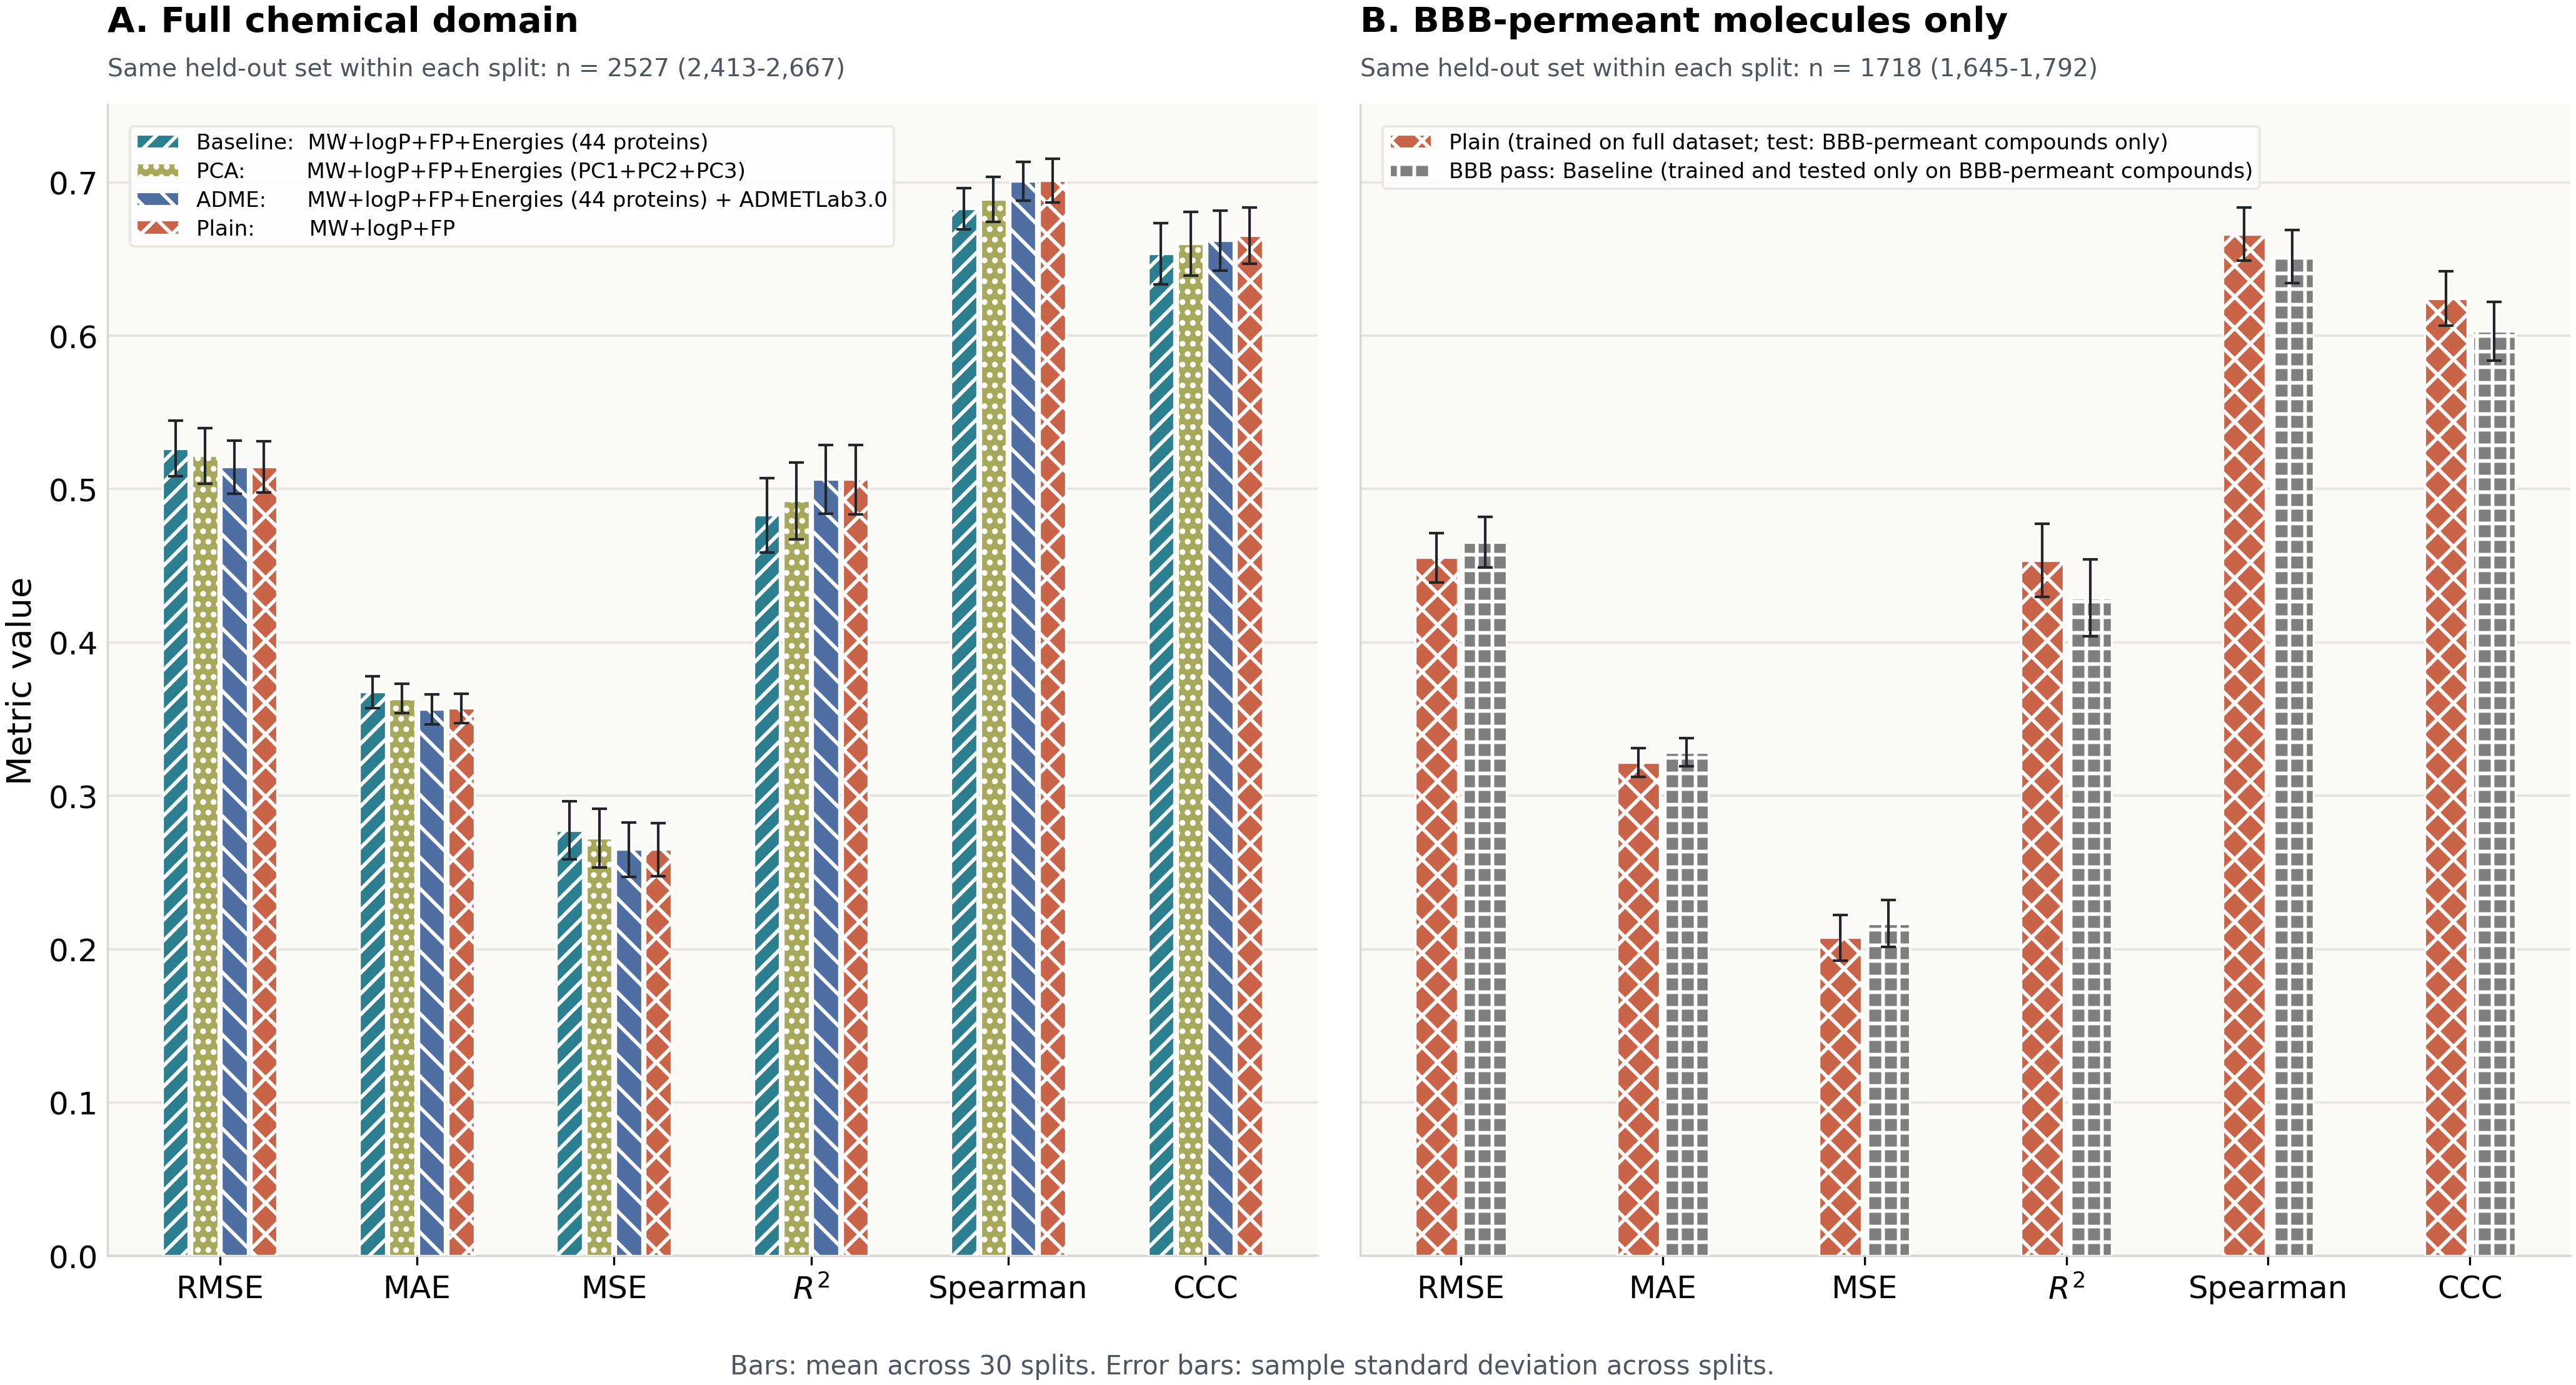

Copied manuscript/fig2.png size=(4121, 2216)


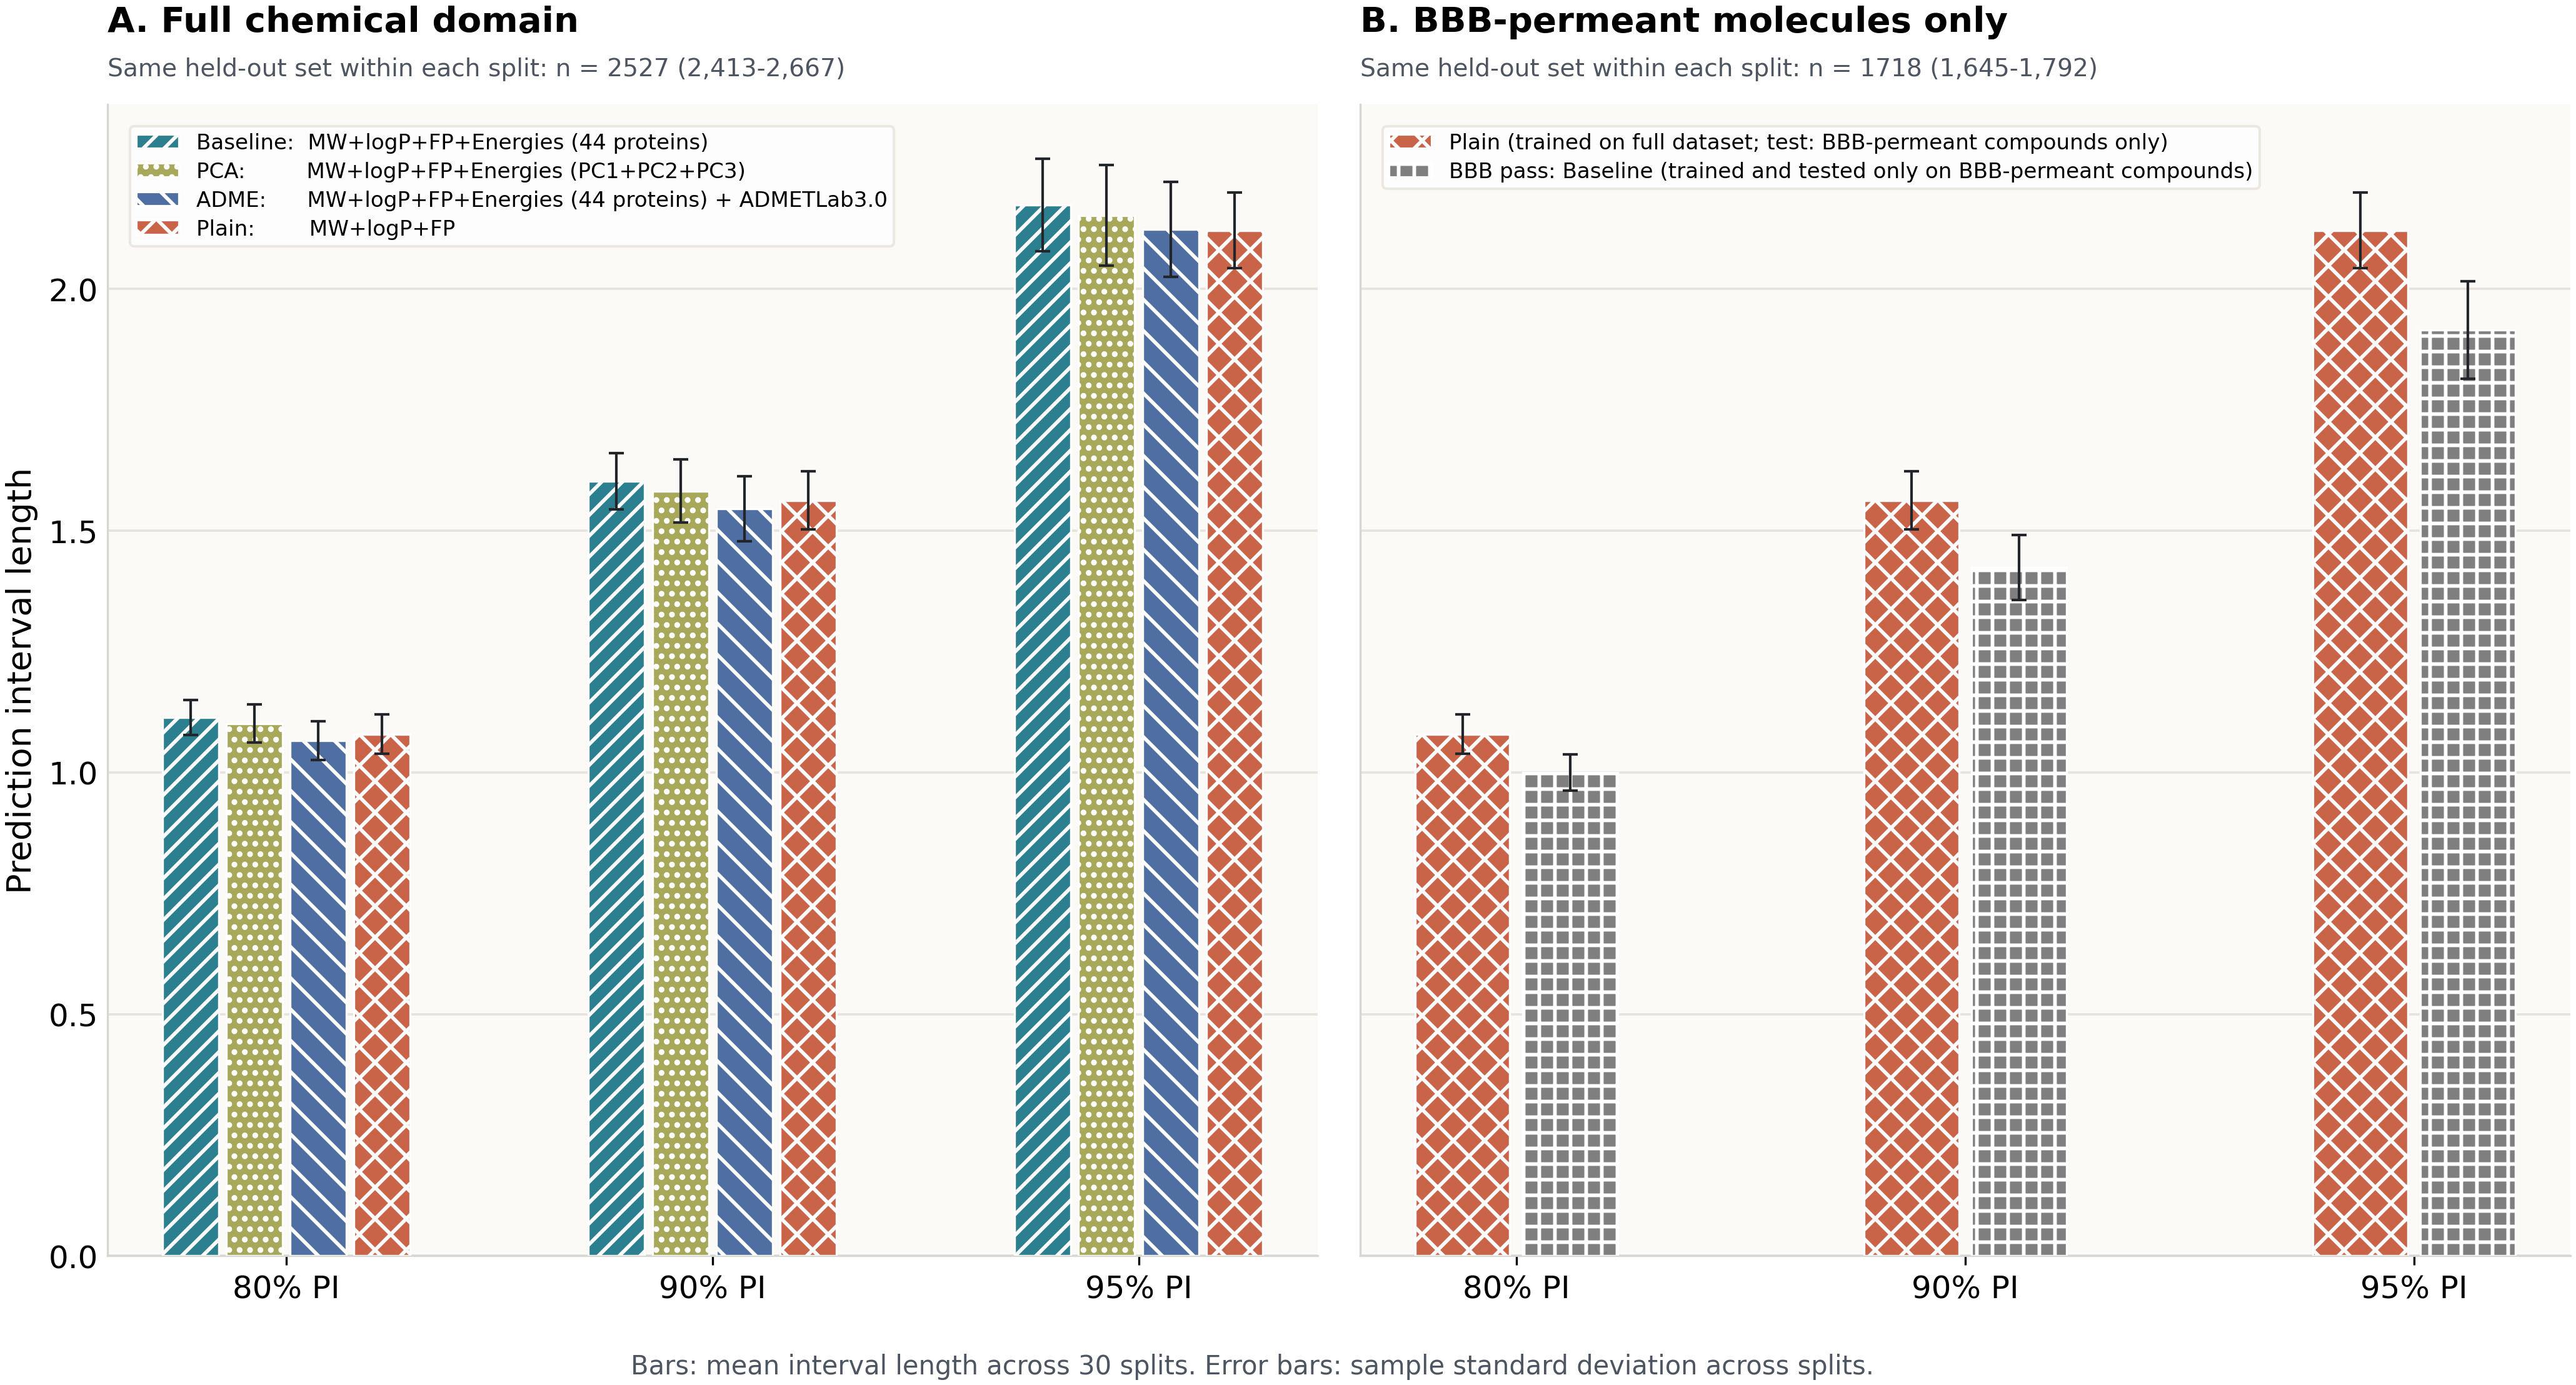

Copied manuscript/fig3.png size=(1812, 1412)


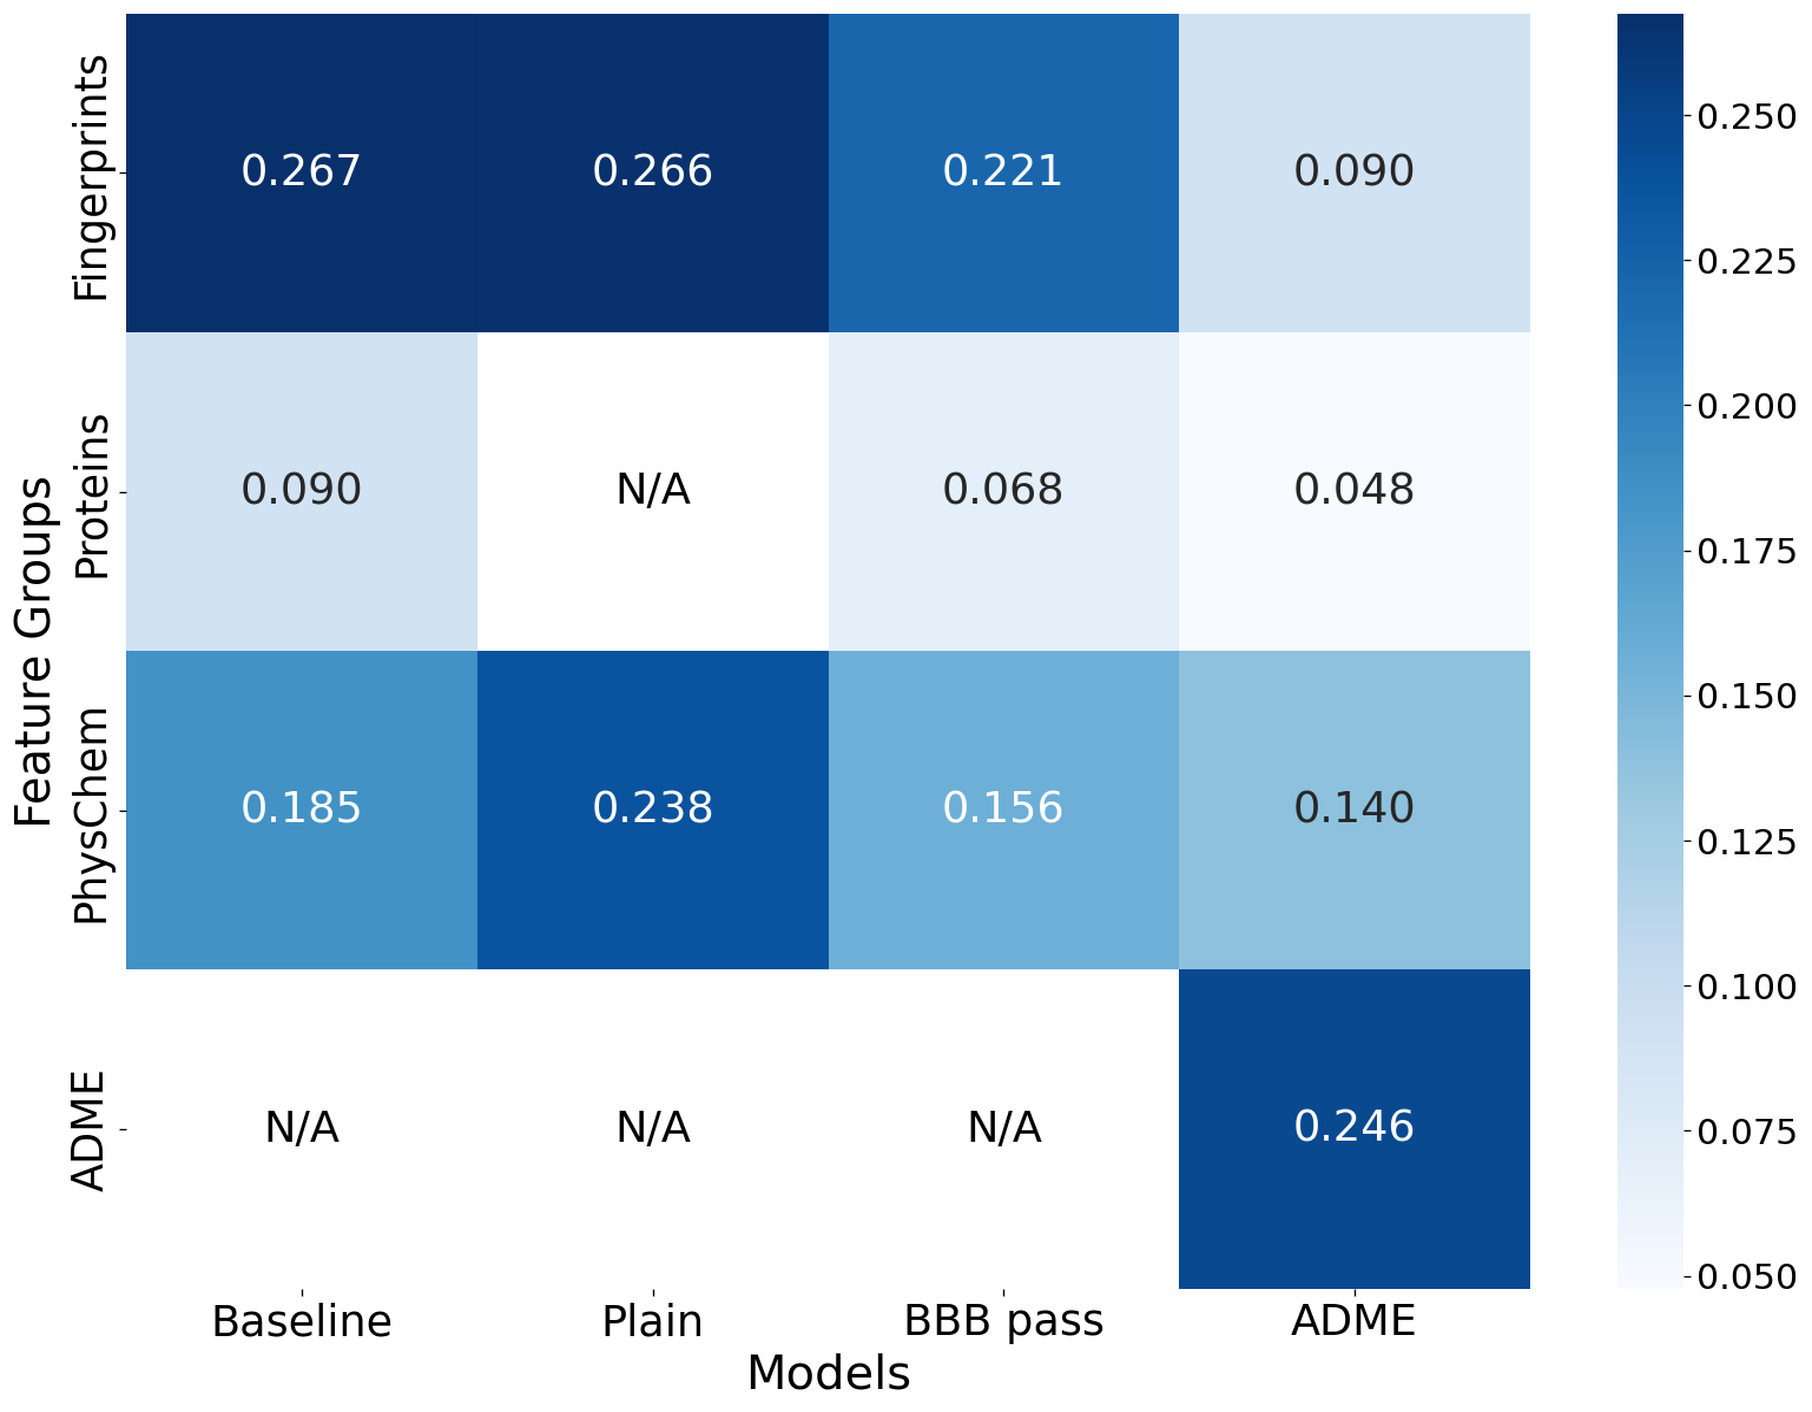

Copied manuscript/fig4a.png size=(2281, 2818)


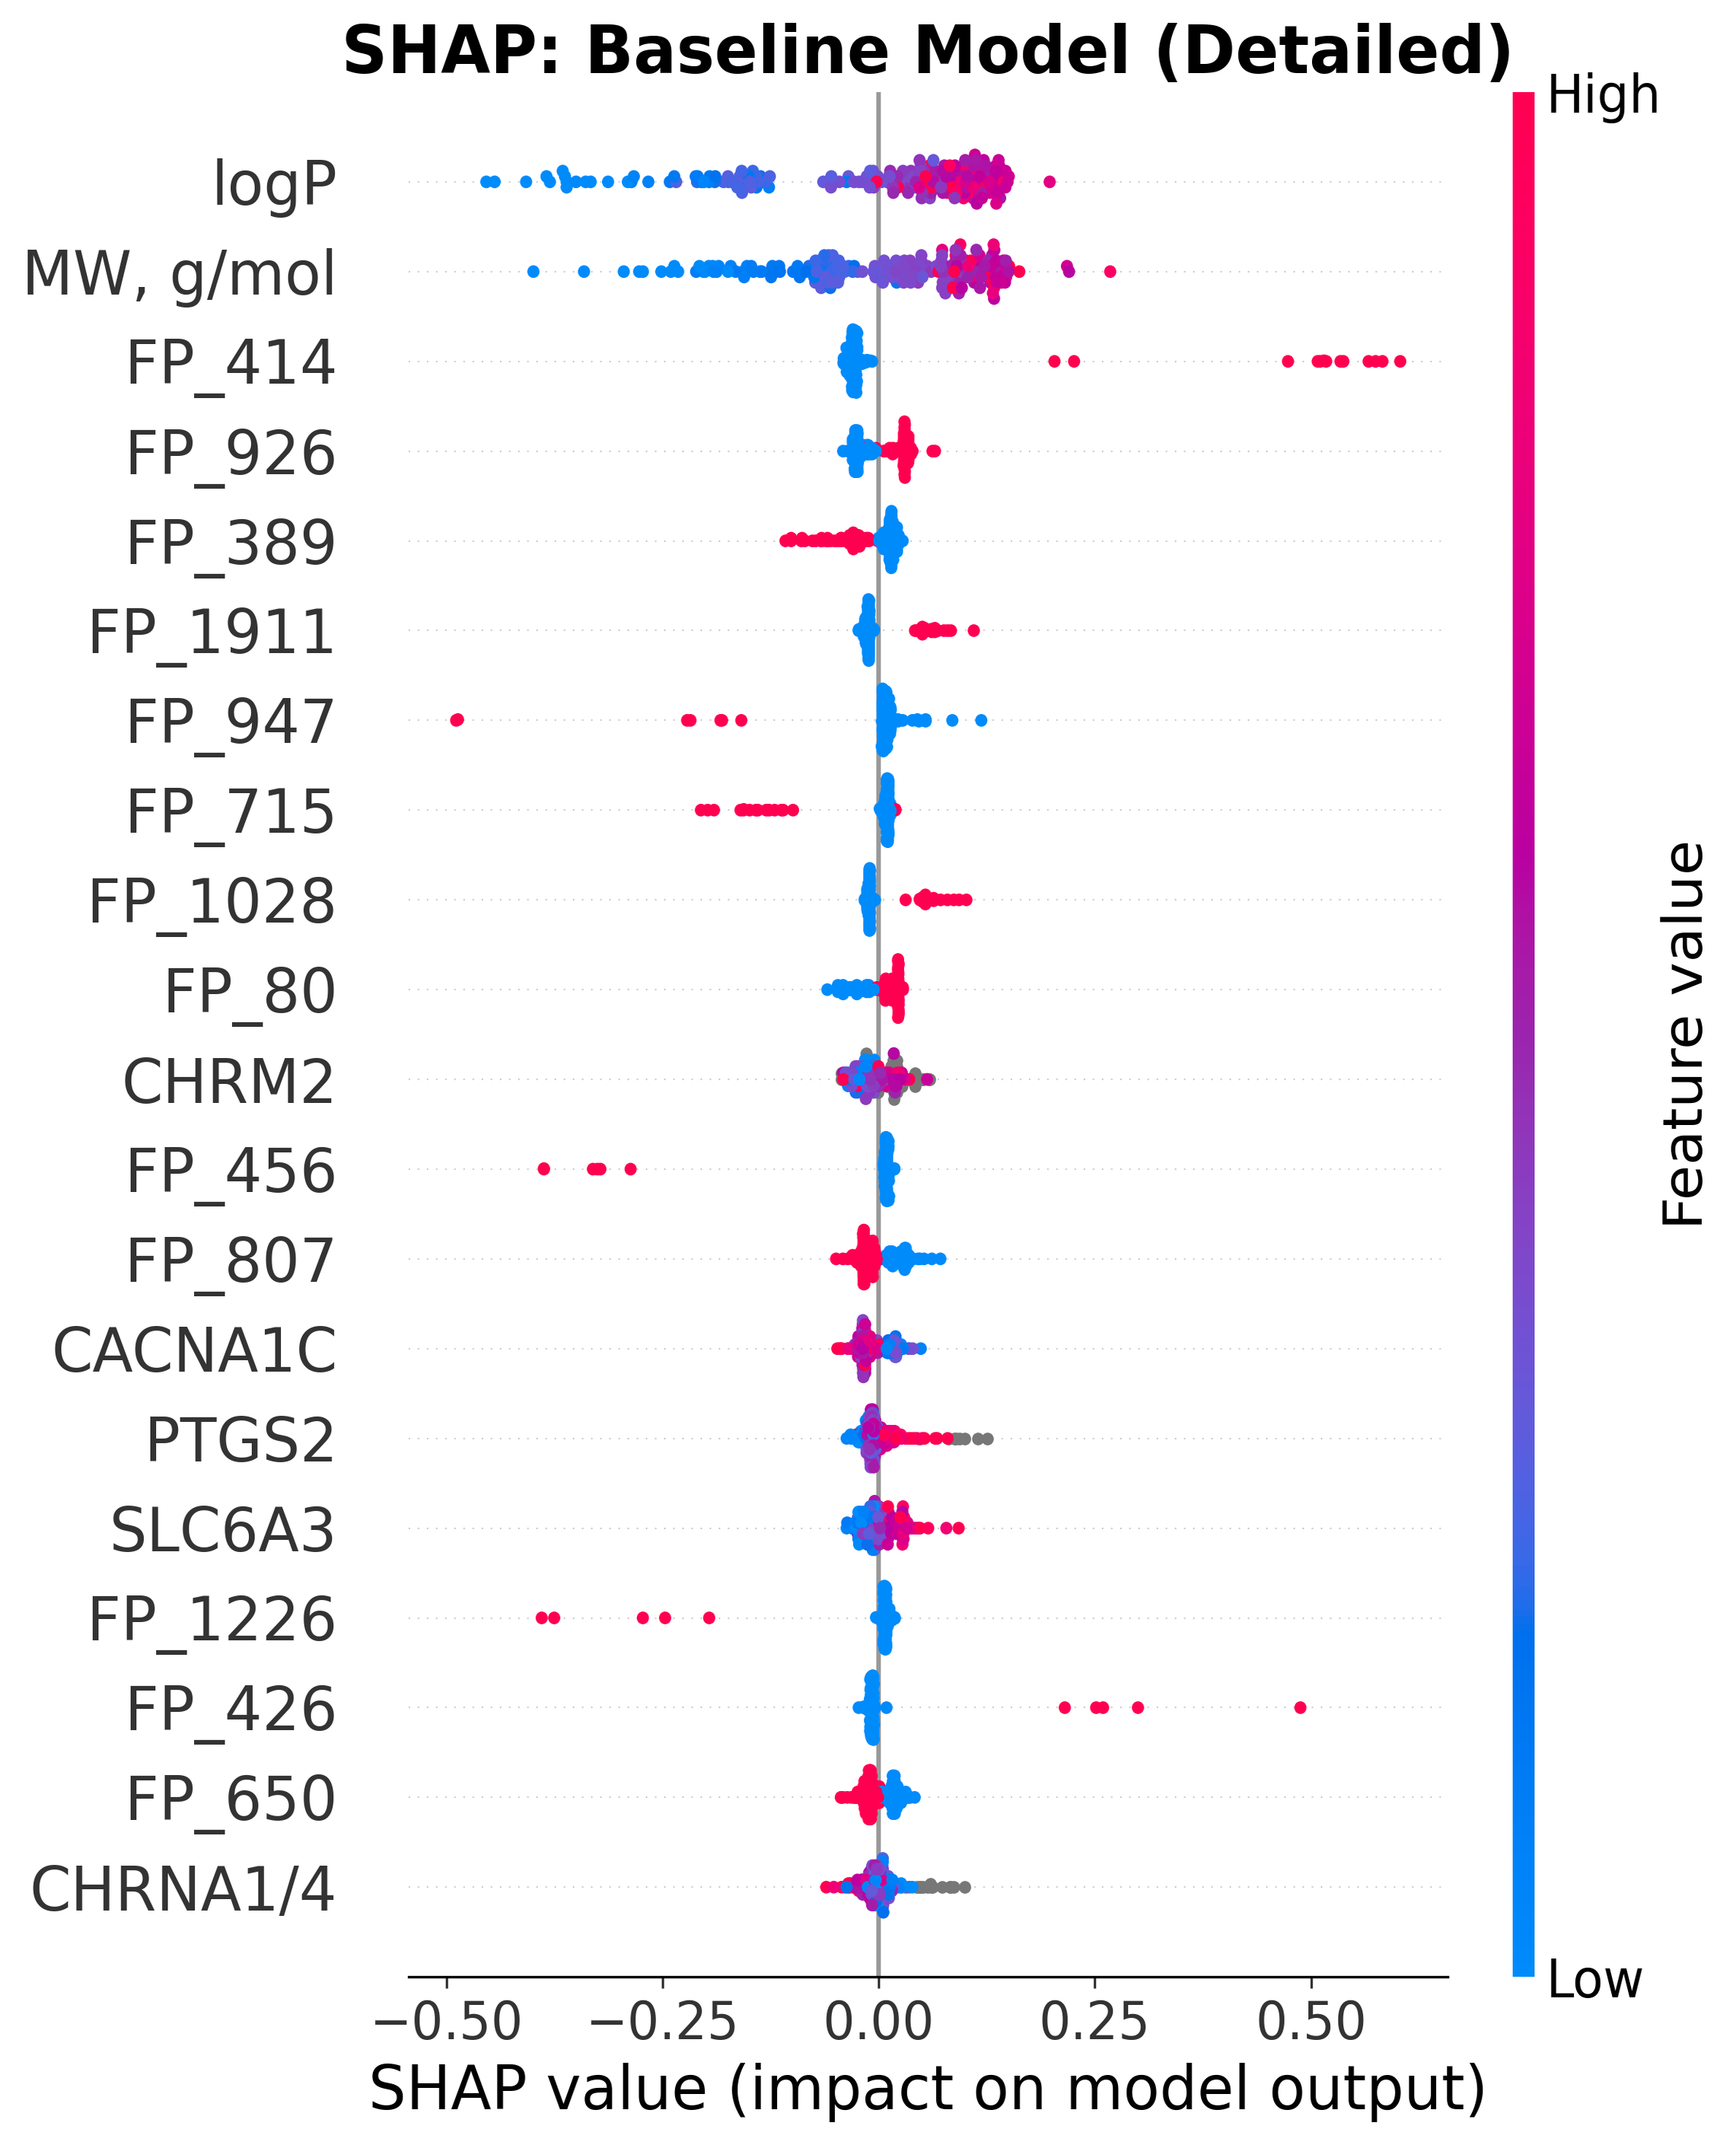

Copied manuscript/fig4b.png size=(2281, 2818)


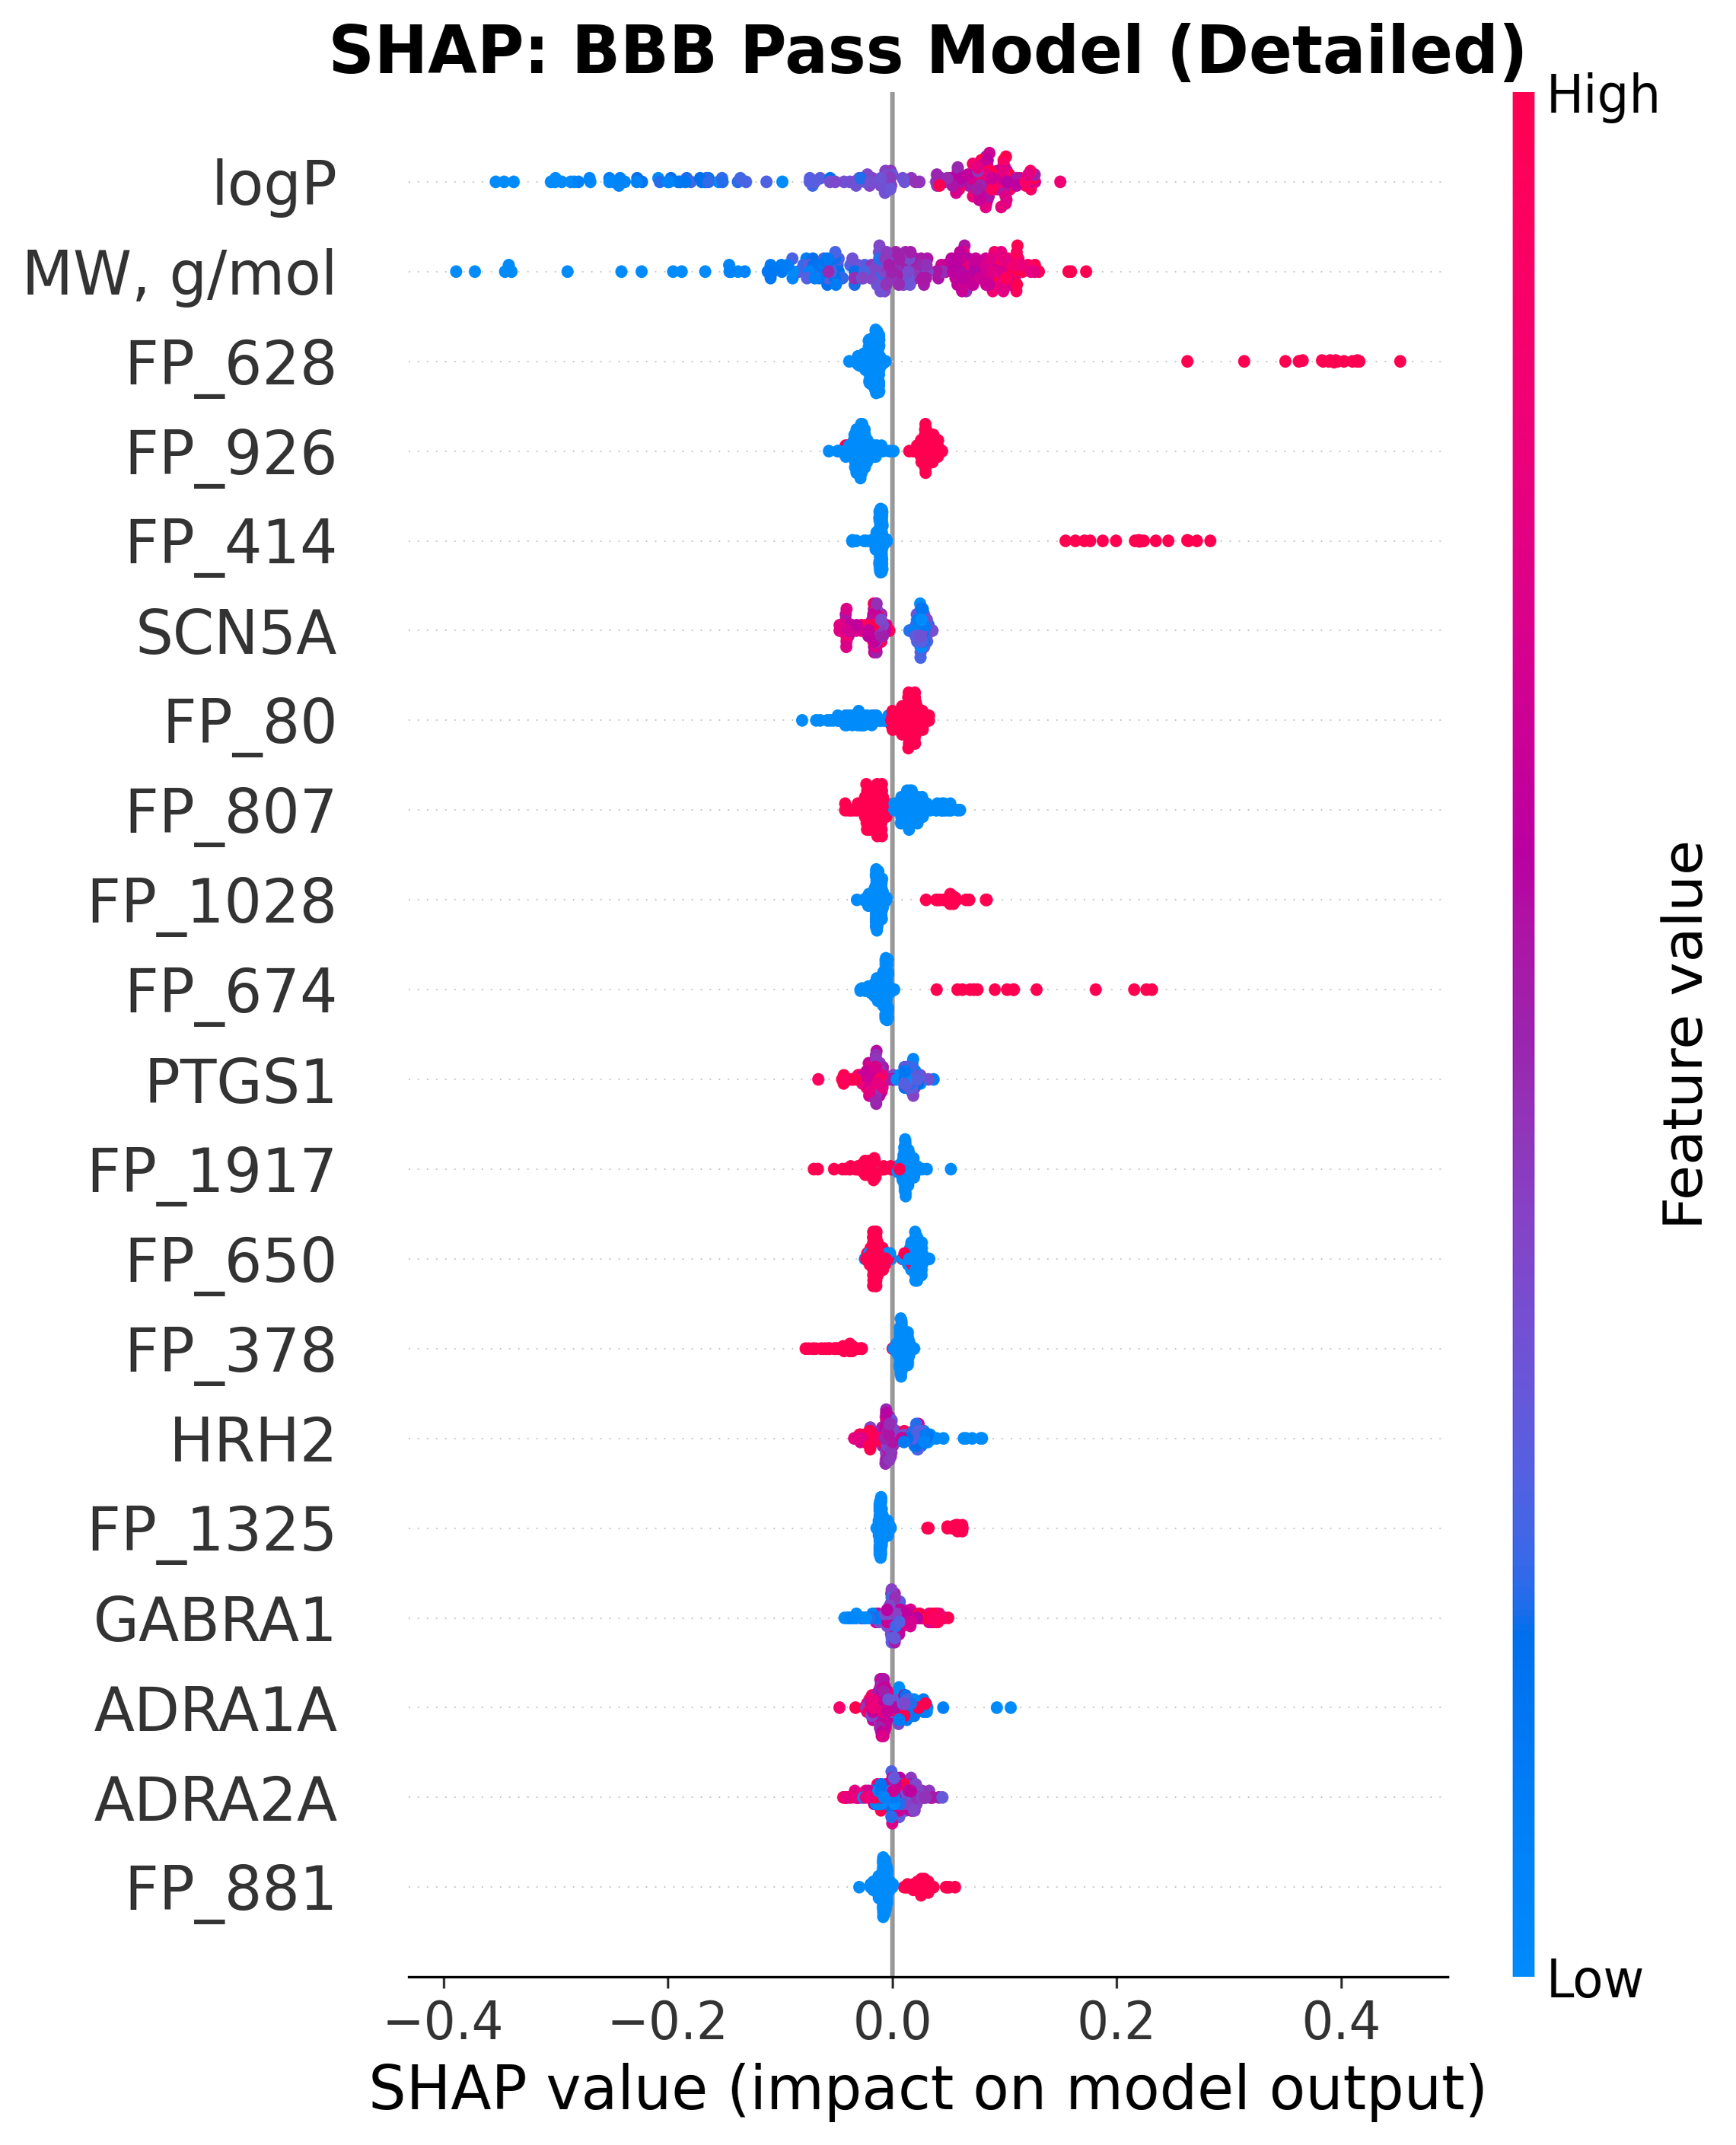

Copied manuscript/fig4c.png size=(2298, 2818)


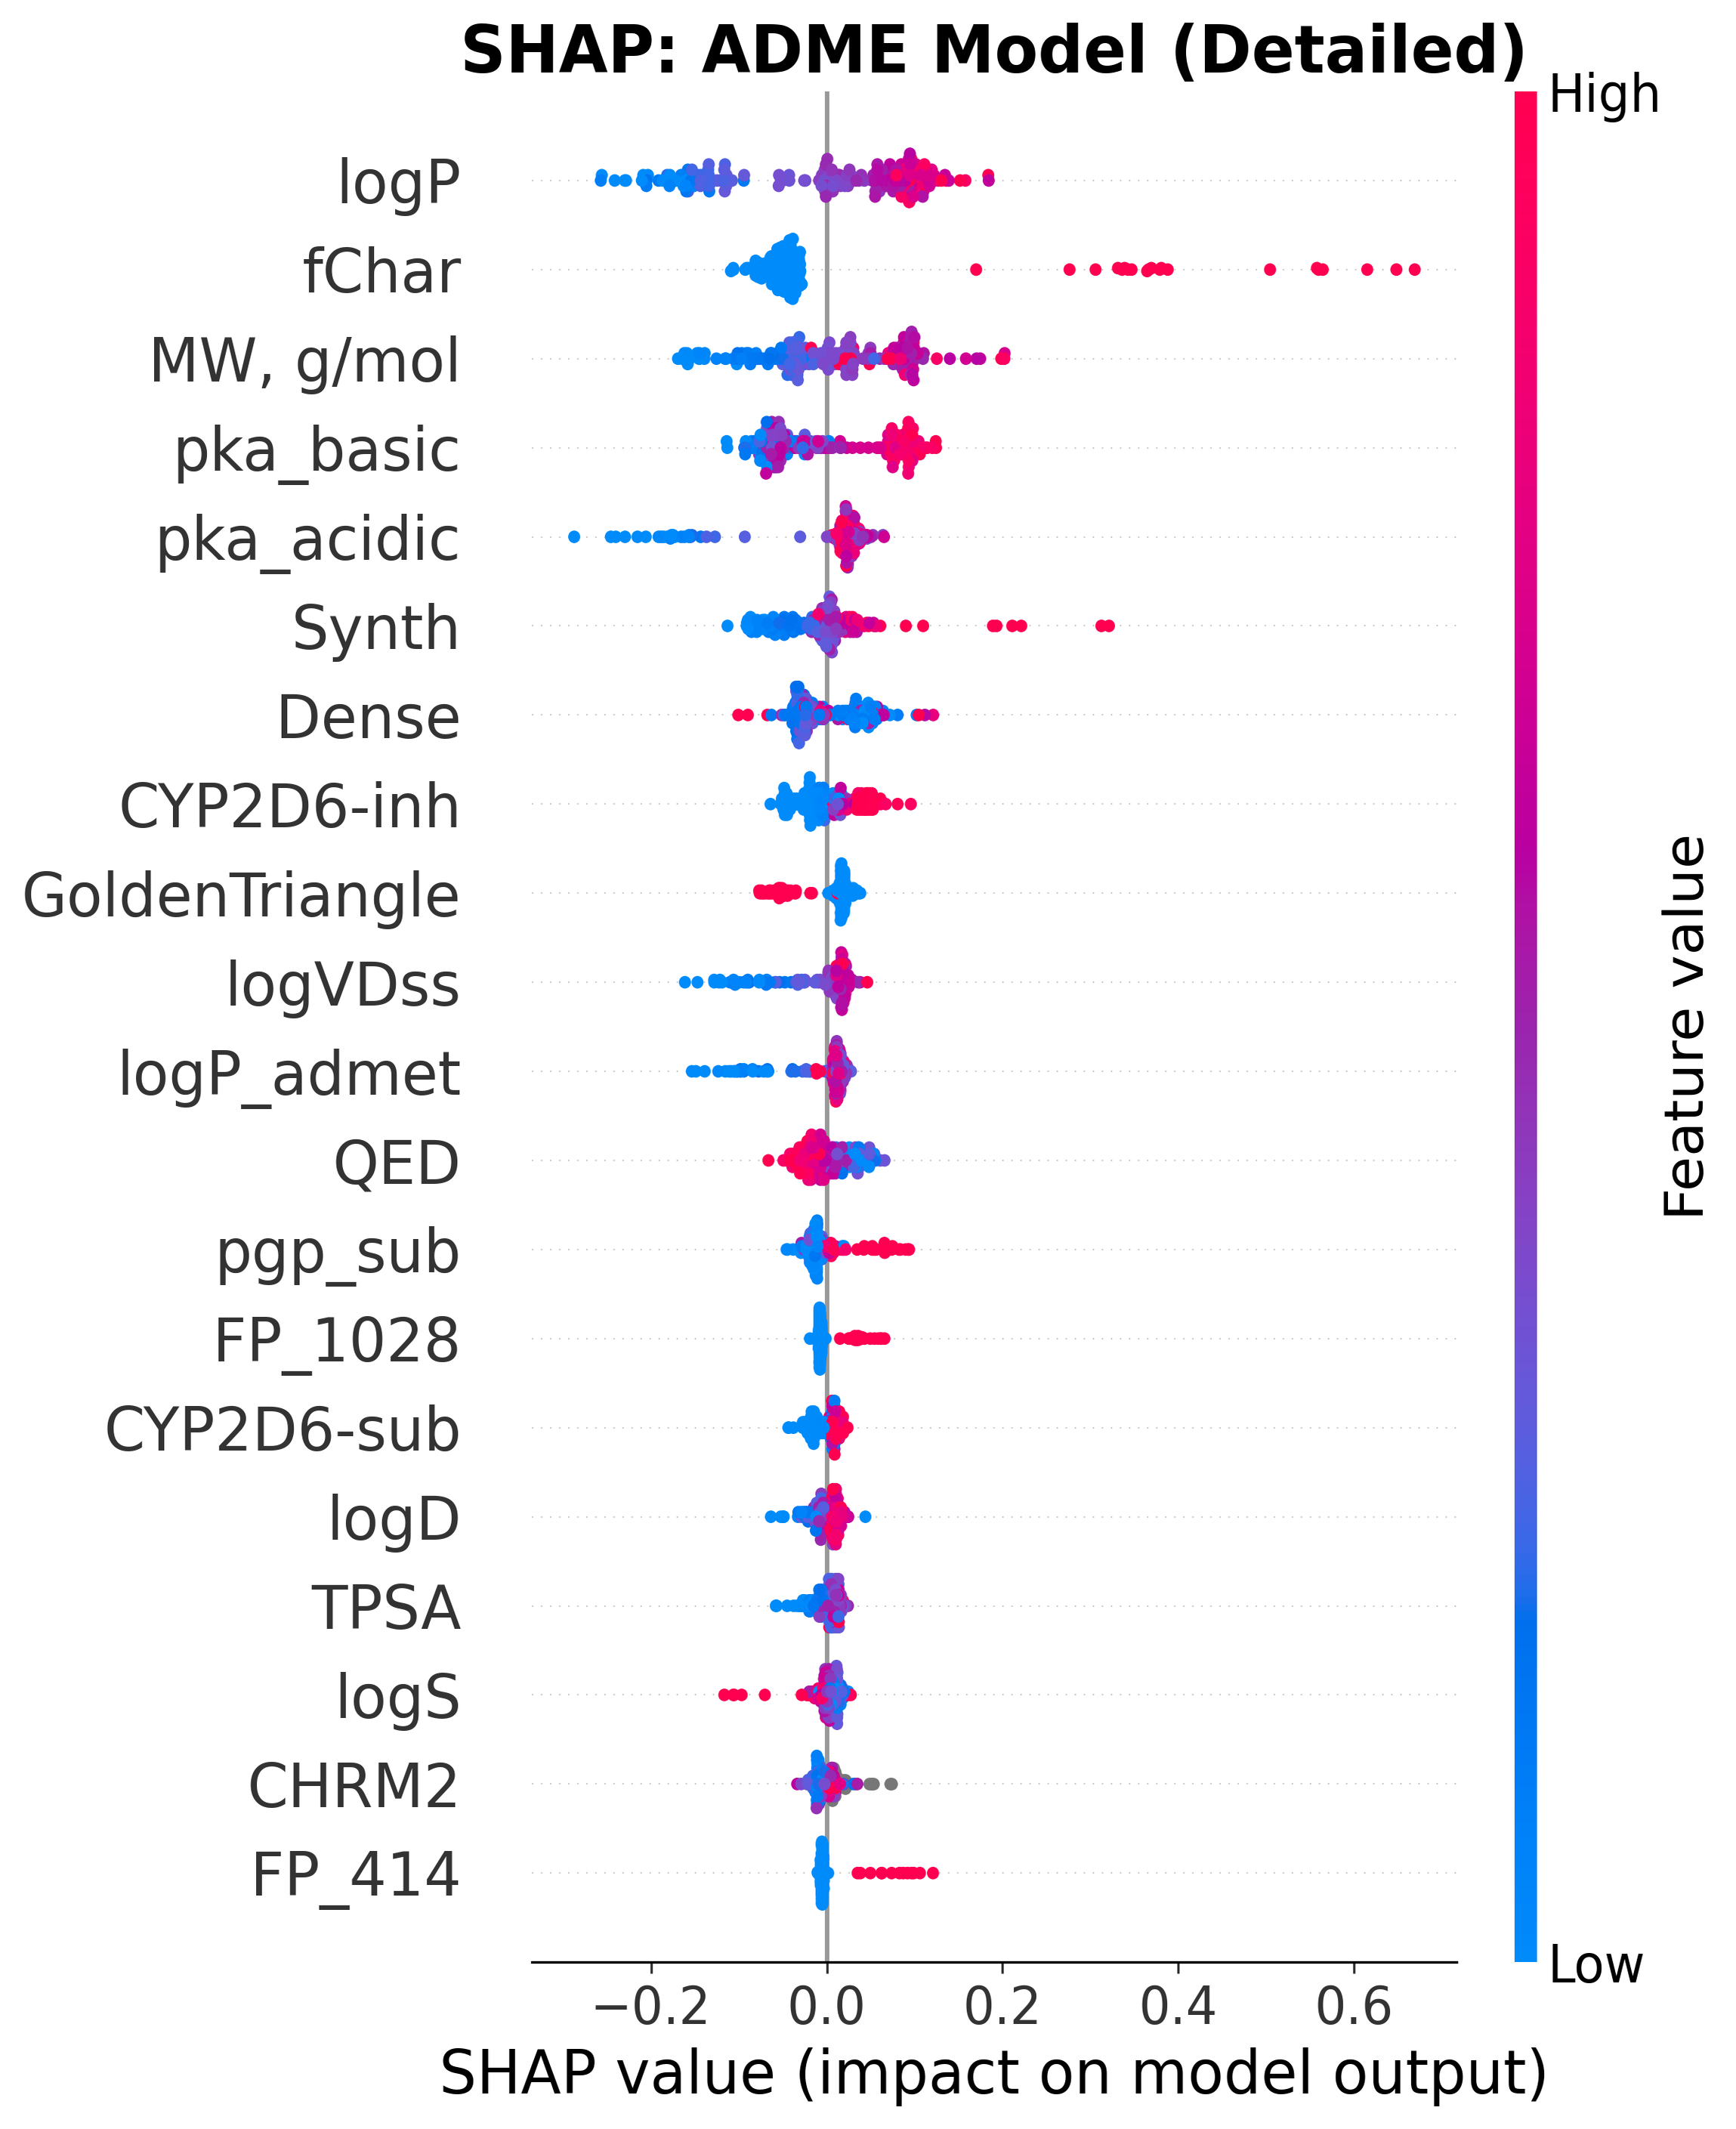

Copied manuscript/fig5.png size=(2284, 2072)


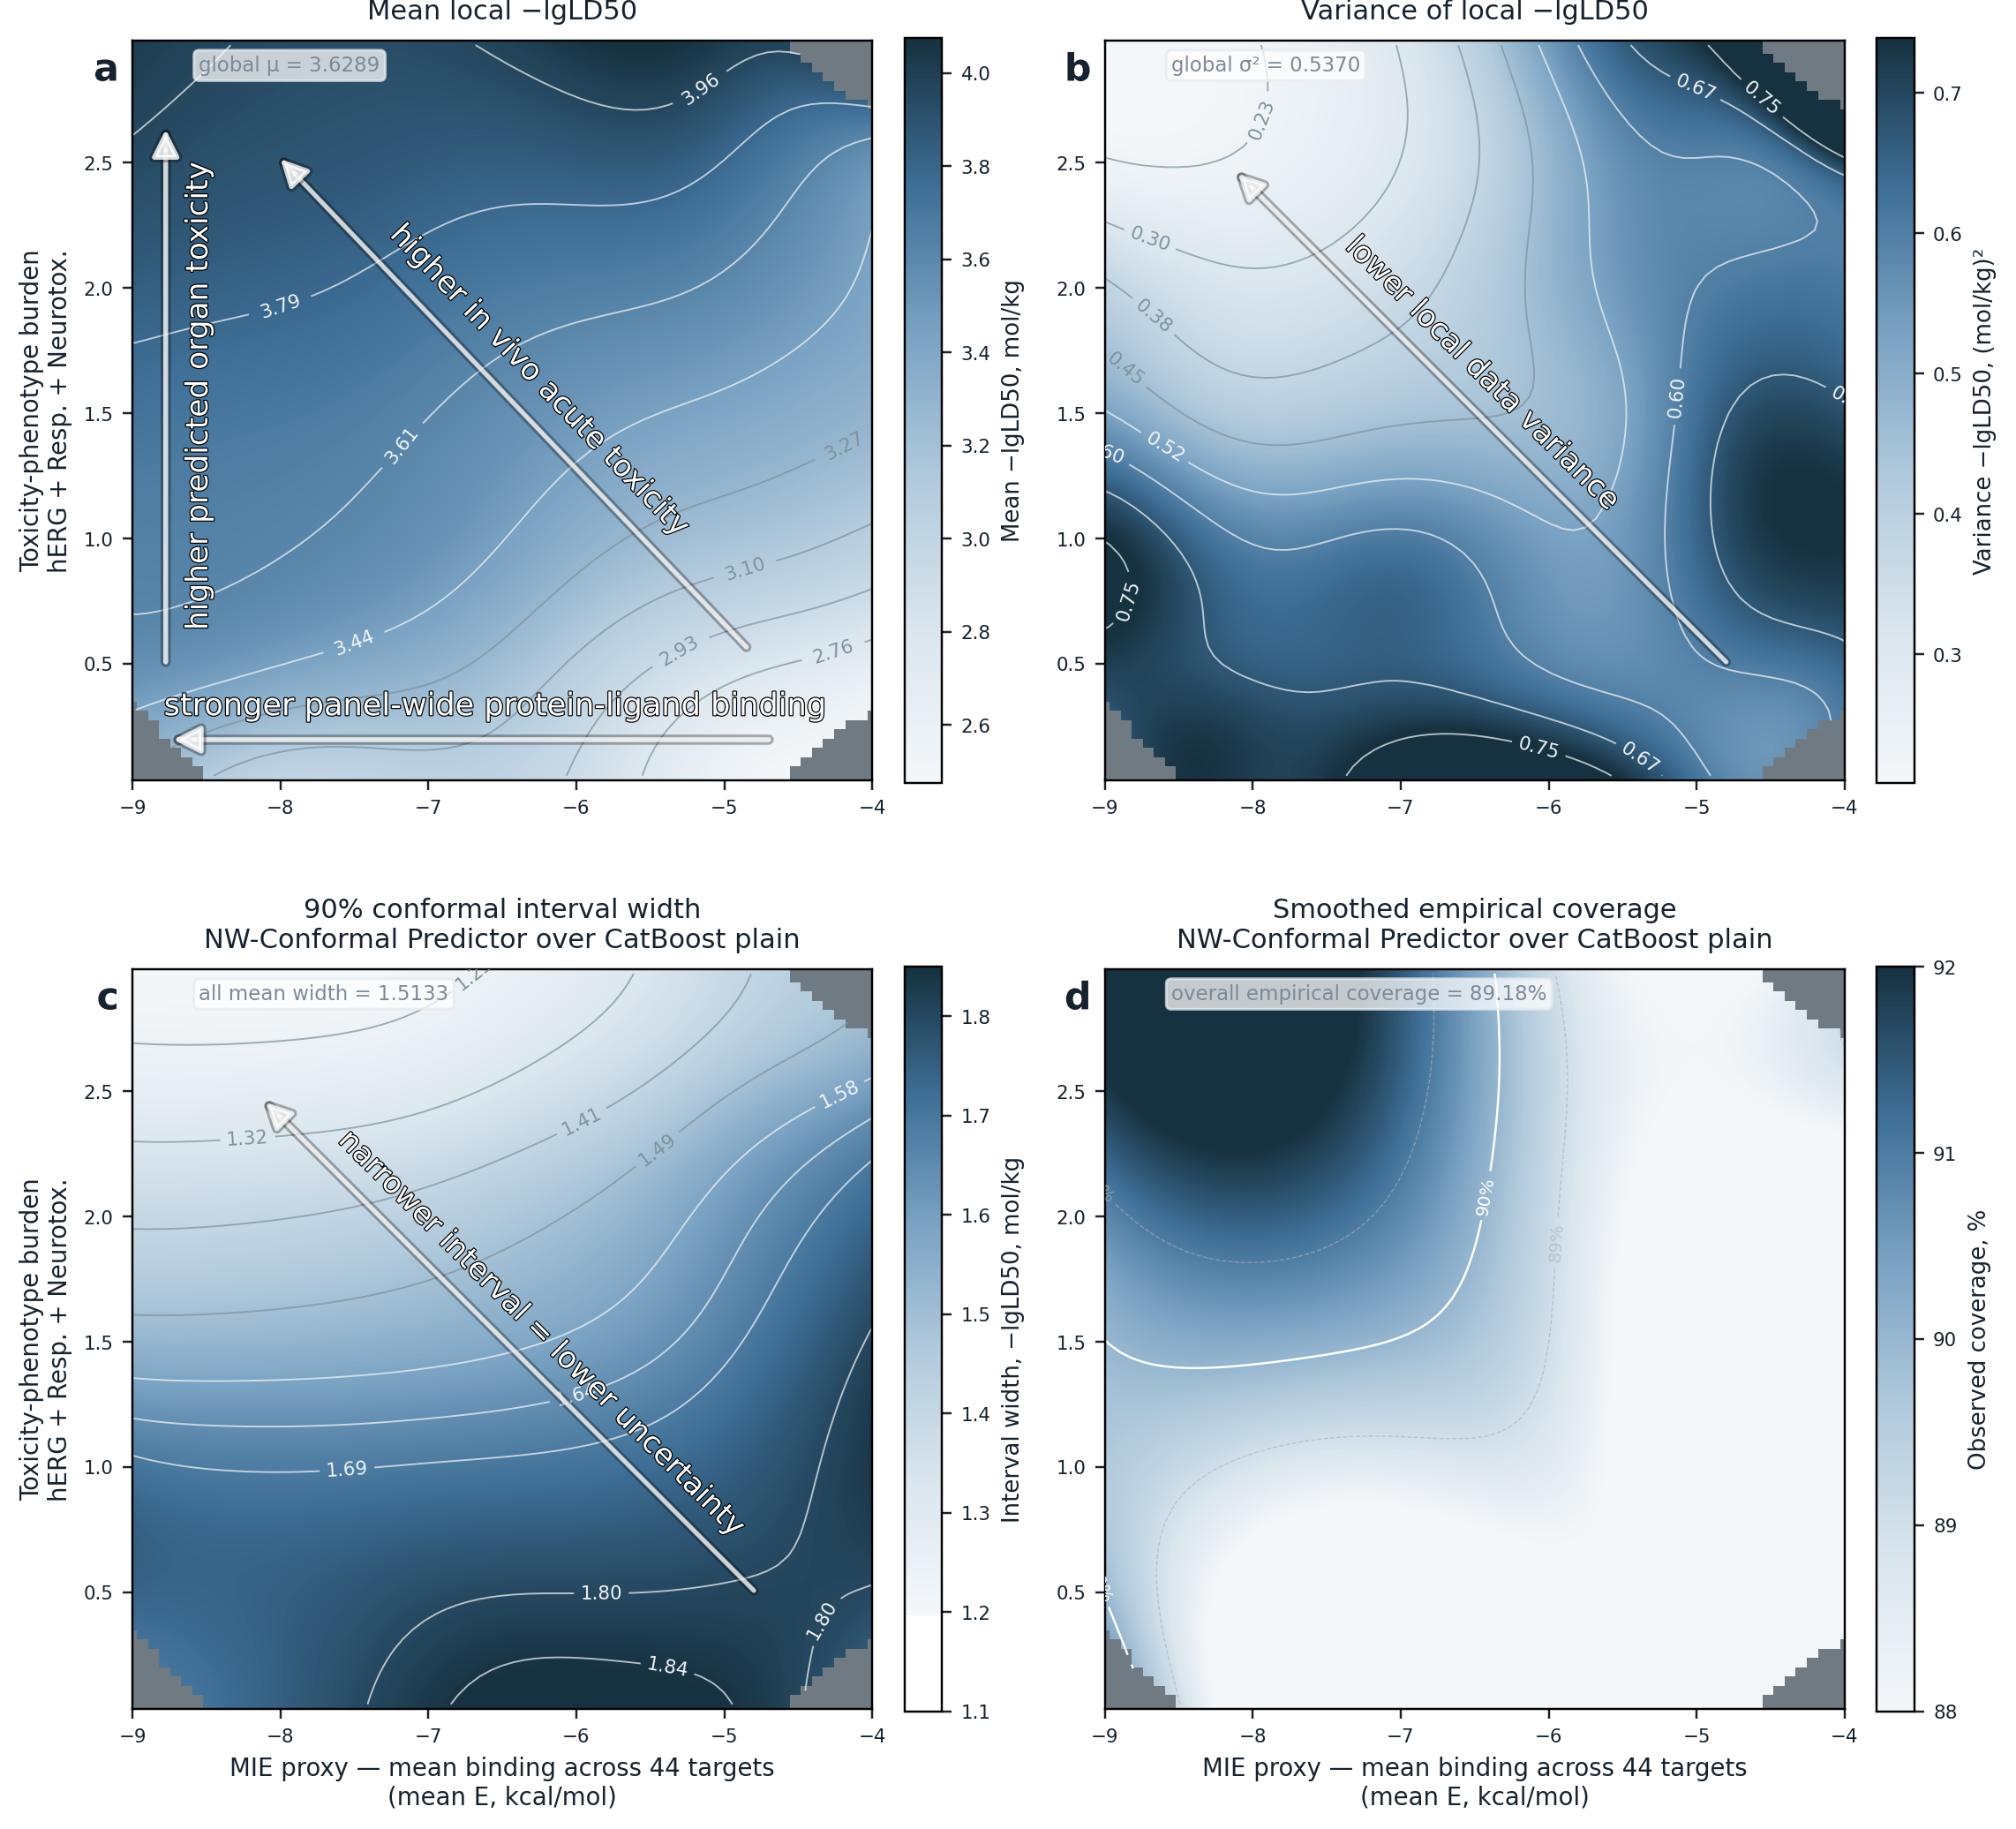

manifest rows 52


In [8]:

# Copy manuscript figures into the LaTeX working directory.
for fig_name in ["fig1.png", "fig2.png", "fig3.png", "fig4a.png", "fig4b.png", "fig4c.png", "fig5.png"]:
    src = MANUSCRIPT_FIGURES / fig_name
    if not src.exists():
        raise FileNotFoundError(src)
    dst = MANUSCRIPT / fig_name
    shutil.copy2(src, dst)
    print(f"Copied {dst.relative_to(ROOT)} size={Image.open(dst).size}")
    display(IPImage(filename=str(dst)))

manifest_rows = []
for path in sorted(list((RESULTS / "tables").glob("*.csv")) + list(MANUSCRIPT_FIGURES.glob("*.png")) + list(GENERATED.glob("*.tex"))):
    manifest_rows.append({"path": str(path.relative_to(ROOT)), "bytes": path.stat().st_size})
pd.DataFrame(manifest_rows).to_csv(TABLES / "artifact_manifest.csv", index=False)
print("manifest rows", len(manifest_rows))
